In [1]:
import pandas as pd
import sqlite3
import os
import matplotlib.pyplot as plt

# 현재 작업 경로 확인
print("현재 작업 폴더:", os.getcwd())

# DB 연결
conn = sqlite3.connect("../db/olist.db")

# customer_unique_id 기준 재구매 고객 요약
repeat_summary = pd.read_sql("""
WITH customer_order_counts AS (
    SELECT
        c.customer_unique_id,
        COUNT(DISTINCT o.order_id) AS order_count
    FROM orders o
    JOIN customers c
        ON o.customer_id = c.customer_id
    GROUP BY c.customer_unique_id
)
SELECT
    COUNT(*) AS total_unique_customers,
    ROUND(AVG(order_count), 2) AS avg_orders_per_customer,
    SUM(CASE WHEN order_count = 1 THEN 1 ELSE 0 END) AS one_time_customers,
    SUM(CASE WHEN order_count >= 2 THEN 1 ELSE 0 END) AS repeat_customers,
    ROUND(SUM(CASE WHEN order_count = 1 THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) AS one_time_customer_pct,
    ROUND(SUM(CASE WHEN order_count >= 2 THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) AS repeat_customer_pct
FROM customer_order_counts;
""", conn)

print(repeat_summary)

현재 작업 폴더: /Users/chaeyoung/Documents/GitHub/olist-ecommerce-analysis/notebooks
   total_unique_customers  avg_orders_per_customer  one_time_customers  \
0                   96096                     1.03               93099   

   repeat_customers  one_time_customer_pct  repeat_customer_pct  
0              2997                  96.88                 3.12  


   order_count  customer_count  customer_pct
0            1           93099         96.88
1            2            2745          2.86
2            3             203          0.21
3            4              30          0.03
4            5               8          0.01
5            6               6          0.01
6            7               3          0.00
7            9               1          0.00
8           17               1          0.00


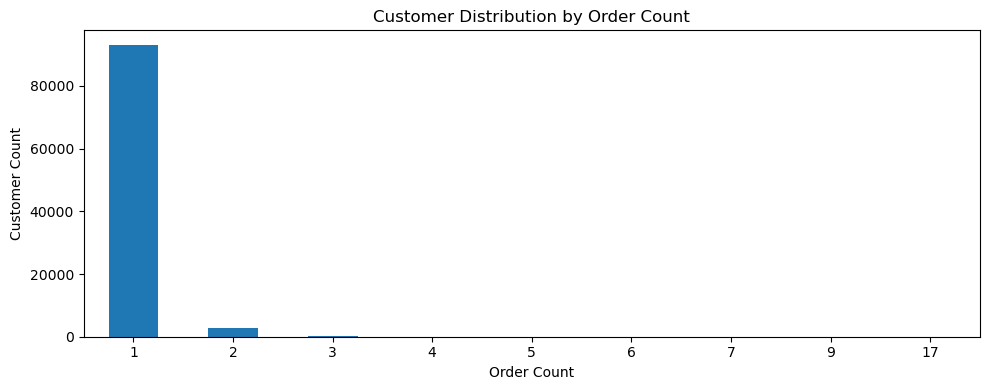

   order_count  customer_count  customer_pct
0            1           93099         96.88
1            2            2745          2.86
2            3             203          0.21
3            4              30          0.03
4            5               8          0.01
5            6               6          0.01
6            7               3          0.00
7            9               1          0.00
8           17               1          0.00


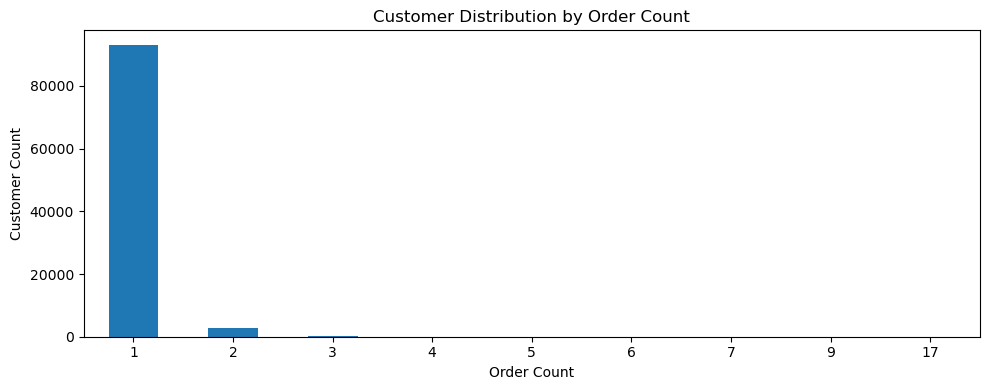

In [2]:
# 고객별 주문 횟수 분포
customer_order_dist = pd.read_sql("""
WITH customer_order_counts AS (
    SELECT
        c.customer_unique_id,
        COUNT(DISTINCT o.order_id) AS order_count
    FROM orders o
    JOIN customers c
        ON o.customer_id = c.customer_id
    GROUP BY c.customer_unique_id
)
SELECT
    order_count,
    COUNT(*) AS customer_count,
    ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM customer_order_counts), 2) AS customer_pct
FROM customer_order_counts
GROUP BY order_count
ORDER BY order_count
LIMIT 10;
""", conn)

print(customer_order_dist)

# 시각화
customer_order_dist.plot(
    kind="bar",
    x="order_count",
    y="customer_count",
    figsize=(10, 4),
    legend=False
)

plt.title("Customer Distribution by Order Count")
plt.xlabel("Order Count")
plt.ylabel("Customer Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()# 고객별 주문 횟수 분포
customer_order_dist = pd.read_sql("""
WITH customer_order_counts AS (
    SELECT
        c.customer_unique_id,
        COUNT(DISTINCT o.order_id) AS order_count
    FROM orders o
    JOIN customers c
        ON o.customer_id = c.customer_id
    GROUP BY c.customer_unique_id
)
SELECT
    order_count,
    COUNT(*) AS customer_count,
    ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM customer_order_counts), 2) AS customer_pct
FROM customer_order_counts
GROUP BY order_count
ORDER BY order_count
LIMIT 10;
""", conn)

print(customer_order_dist)

# 시각화
customer_order_dist.plot(
    kind="bar",
    x="order_count",
    y="customer_count",
    figsize=(10, 4),
    legend=False
)

plt.title("Customer Distribution by Order Count")
plt.xlabel("Order Count")
plt.ylabel("Customer Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

  order_month  new_customers  repeat_customers
0     2016-09              4                 0
1     2016-10            321                 0
2     2016-12              1                 0
3     2017-01            764                 1
4     2017-02           1752                 3


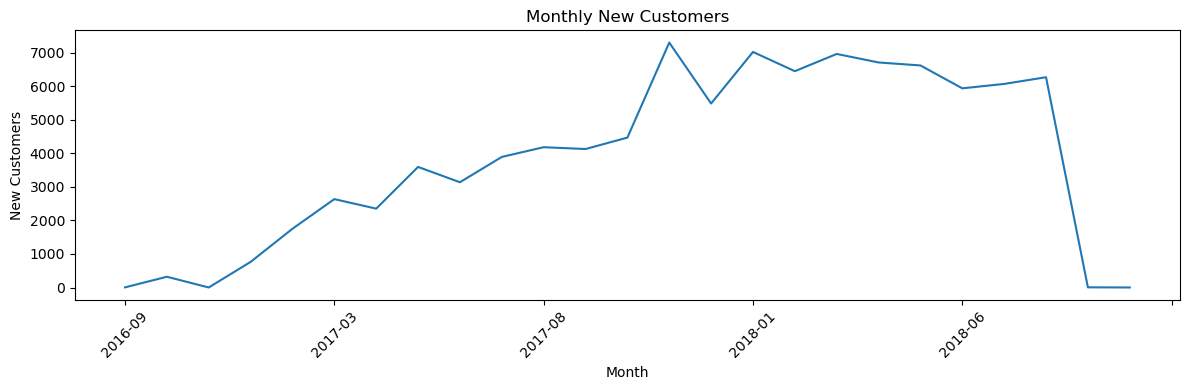

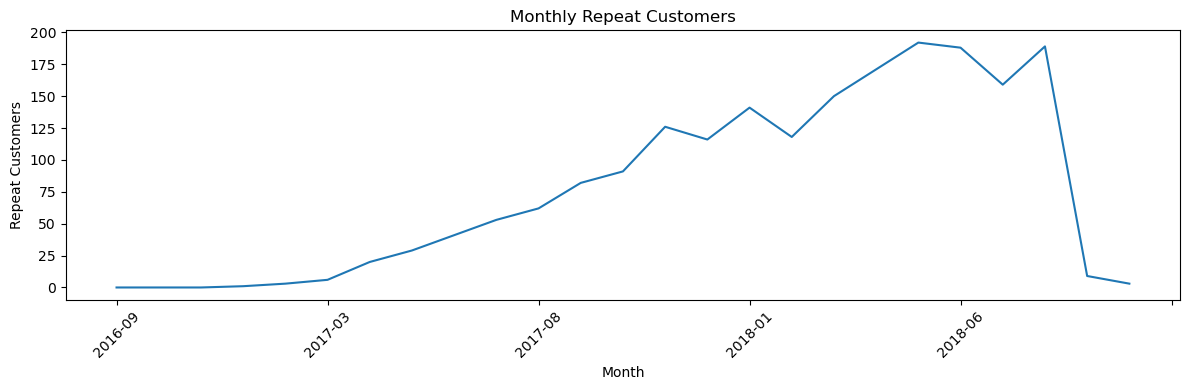

In [3]:
# 월별 신규 고객 / 재구매 고객 수 분석
monthly_customer_type = pd.read_sql("""
WITH customer_orders AS (
    SELECT
        c.customer_unique_id,
        strftime('%Y-%m', o.order_purchase_timestamp) AS order_month,
        MIN(strftime('%Y-%m', o.order_purchase_timestamp)) OVER (
            PARTITION BY c.customer_unique_id
        ) AS first_order_month
    FROM orders o
    JOIN customers c
        ON o.customer_id = c.customer_id
    WHERE o.order_purchase_timestamp IS NOT NULL
),
monthly_summary AS (
    SELECT
        order_month,
        COUNT(DISTINCT CASE WHEN order_month = first_order_month THEN customer_unique_id END) AS new_customers,
        COUNT(DISTINCT CASE WHEN order_month > first_order_month THEN customer_unique_id END) AS repeat_customers
    FROM customer_orders
    GROUP BY order_month
)
SELECT
    order_month,
    new_customers,
    repeat_customers
FROM monthly_summary
ORDER BY order_month;
""", conn)

print(monthly_customer_type.head())

# 월별 신규 고객 수
monthly_customer_type.plot(
    x="order_month",
    y="new_customers",
    figsize=(12, 4),
    legend=False
)

plt.title("Monthly New Customers")
plt.xlabel("Month")
plt.ylabel("New Customers")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 월별 재구매 고객 수
monthly_customer_type.plot(
    x="order_month",
    y="repeat_customers",
    figsize=(12, 4),
    legend=False
)

plt.title("Monthly Repeat Customers")
plt.xlabel("Month")
plt.ylabel("Repeat Customers")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

   customer_state  total_customers  repeat_customers  repeat_customer_pct
0              RO              240                10                 4.17
1              RJ            12384               421                 3.40
2              MT              876                29                 3.31
3              GO             1952                64                 3.28
4              SP            40302              1296                 3.22
5              RS             5277               167                 3.16
6              MG            11259               338                 3.00
7              DF             2075                62                 2.99
8              AL              401                12                 2.99
9              PR             4882               145                 2.97
10             ES             1964                57                 2.90
11             BA             3277                93                 2.84
12             SC             3534    

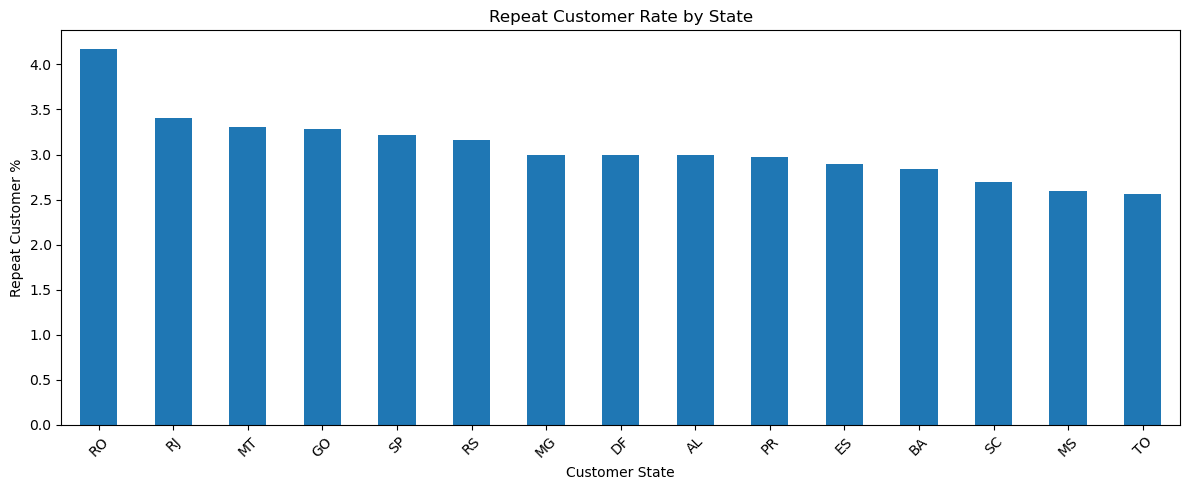

In [4]:
# 고객 주(state) 기준 재구매 고객 비율 분석
state_repeat_rate = pd.read_sql("""
WITH customer_order_counts AS (
    SELECT
        c.customer_unique_id,
        c.customer_state,
        COUNT(DISTINCT o.order_id) AS order_count
    FROM orders o
    JOIN customers c
        ON o.customer_id = c.customer_id
    GROUP BY c.customer_unique_id, c.customer_state
)
SELECT
    customer_state,
    COUNT(*) AS total_customers,
    SUM(CASE WHEN order_count >= 2 THEN 1 ELSE 0 END) AS repeat_customers,
    ROUND(SUM(CASE WHEN order_count >= 2 THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) AS repeat_customer_pct
FROM customer_order_counts
GROUP BY customer_state
HAVING COUNT(*) >= 100
ORDER BY repeat_customer_pct DESC
LIMIT 15;
""", conn)

print(state_repeat_rate)

# 시각화
state_repeat_rate.plot(
    kind="bar",
    x="customer_state",
    y="repeat_customer_pct",
    figsize=(12, 5),
    legend=False
)

plt.title("Repeat Customer Rate by State")
plt.xlabel("Customer State")
plt.ylabel("Repeat Customer %")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()